# Exploratory Data Analysis (EDA) on Titanic Dataset  

---

## My Introduction
- Name: Aleem Shoukat
- D.A Elevvo Pathways (TASK-05)
- Date - 07/Sept/2025  
 

---

## Task Introduction
- Dataset: Titanic passenger data (1912 shipwreck)  
- Includes: Age, Sex, Class, Fare, Survival status  
- Purpose: Analyze survival patterns and key influencing factors  

---

## Objectives
- Clean and preprocess data (handle missing values, encoding)  
- Generate summary statistics and insights  
- Visualize survival trends by gender, class, age, etc.  
- Explore correlations between variables  
- Summarize key findings  


In [12]:
import pandas as pd
df=pd.read_csv("Titanic_train.csv")
df.head()
print("Rows and Columns".center(80))
print(df.shape)
print("Columns Names".center(80))
print(df.columns.tolist())
print("Info of DataSet".center(80))
print(df.info())
print("Checking Missing values".center(80))
print(df.isnull().sum())

#Okay so Handle missing values in Columns (Age,Cabin and Embarked)

df['Age']=df['Age'].fillna(df['Age'].median()) #Replaced Missing Age with Median
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0]) #Missing Embarked Value with most frequent value
df.drop(columns=['Cabin'], inplace=True) #Due to alot of missing values in Cabin I drop it.

#Now Encoding some categorical Columns (Sex and Embarked)
df['Sex']=df['Sex'].map({'male':0,'female':1}) 
df['Embarked']=df['Embarked'].map({'C':0,'Q':1,'S':3}) 

#Checking Duplicates
print(df.duplicated().sum()) #So no duplicate value found

# 4. Final dataset info after cleaning
print("After Cleaning".center(80, "-"))
print(df.info())
print("\nMissing Values After Cleaning:\n", df.isnull().sum())


#Save the cleaned dataset
df.to_csv("Titanic_Cleaned.csv",index=False)
print("Save Cleaned file name as ...Titanic_Cleaned.csv...") 

                                Rows and Columns                                
(891, 12)
                                 Columns Names                                  
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
                                Info of DataSet                                 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204

Shape of Dataset: (891, 11)
Column Names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']
-------------------------------Summary Statistics-------------------------------
              Age        Fare       SibSp       Parch  FamilySize
count  891.000000  891.000000  891.000000  891.000000  891.000000
mean    29.361582   32.204208    0.523008    0.381594    1.904602
std     13.019697   49.693429    1.102743    0.806057    1.613459
min      0.420000    0.000000    0.000000    0.000000    1.000000
25%     22.000000    7.910400    0.000000    0.000000    1.000000
50%     28.000000   14.454200    0.000000    0.000000    1.000000
75%     35.000000   31.000000    1.000000    0.000000    2.000000
max     80.000000  512.329200    8.000000    6.000000   11.000000

Survival by Sex:
 Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64

Survival by Pclass:
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype:

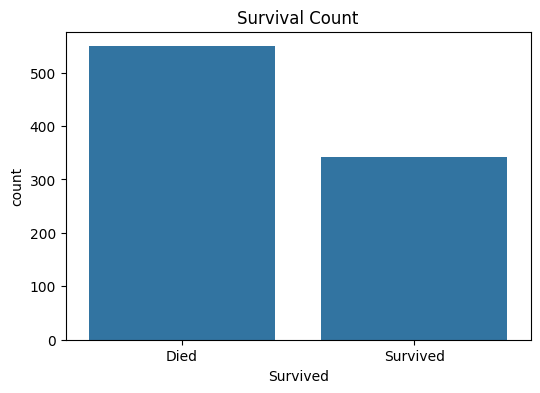

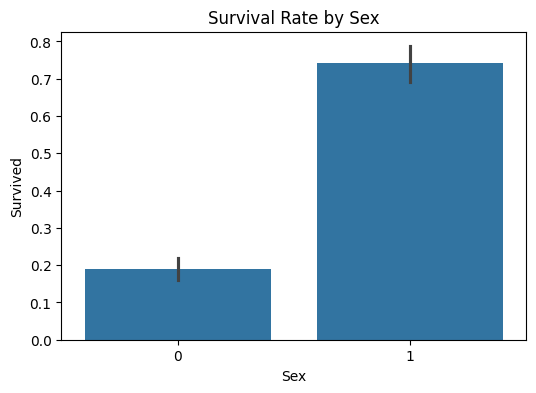

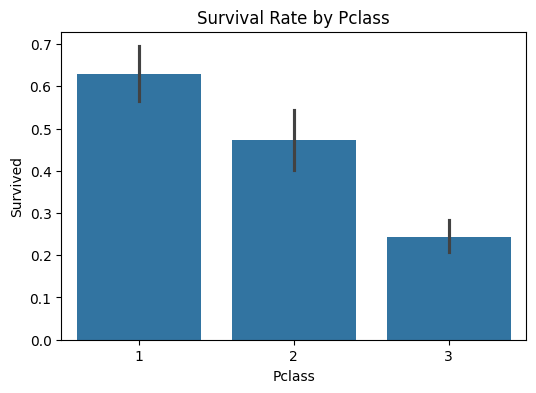

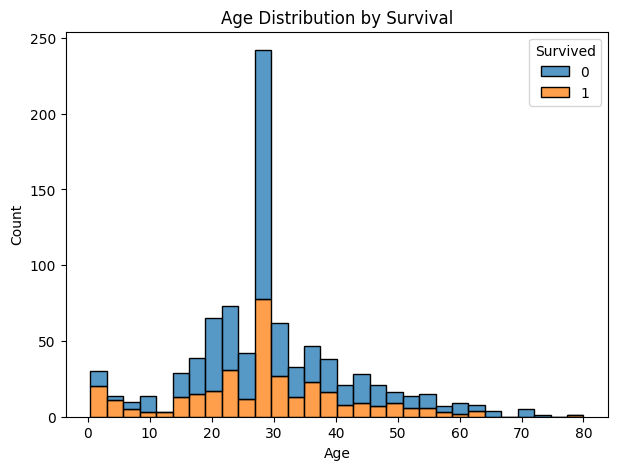

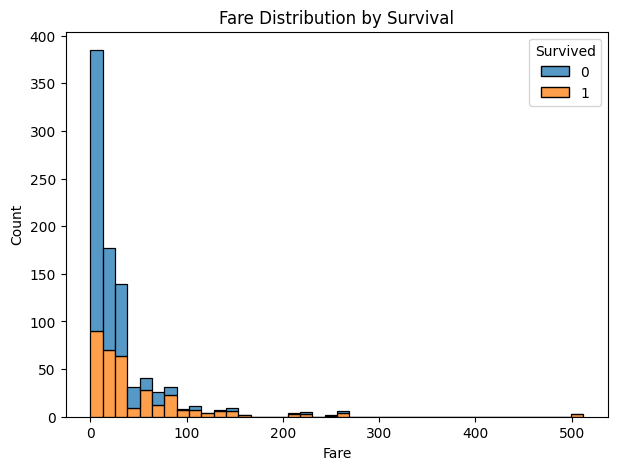

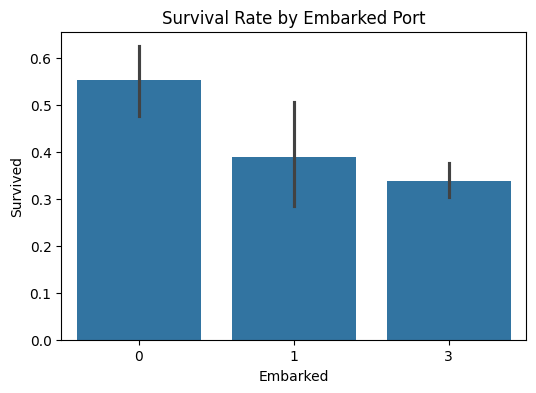

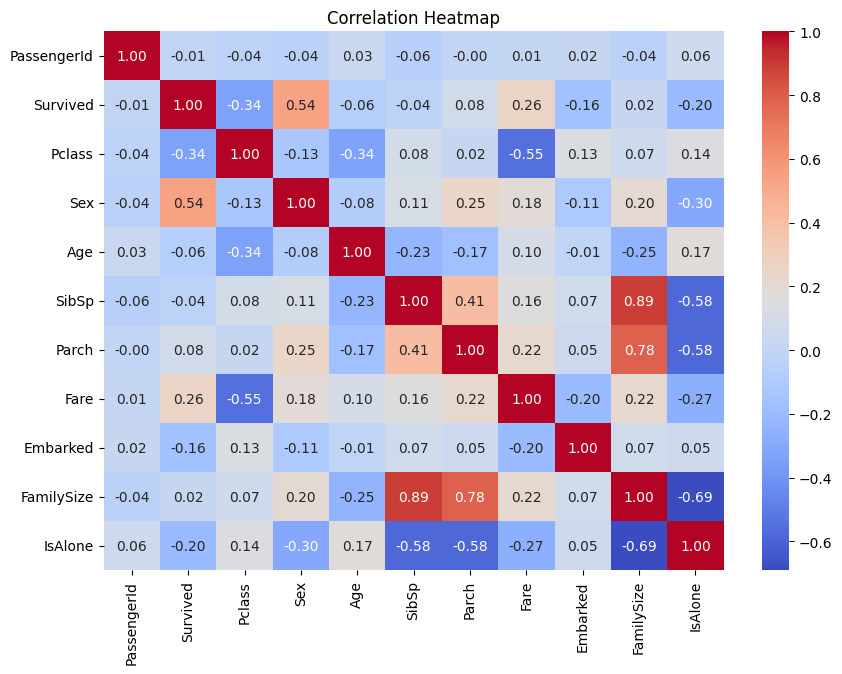

Key outputs saved as CSV files: survival_by_sex.csv, survival_by_pclass.csv, survival_by_ageband.csv


In [11]:

                                         # Exploratory Data Analysis (EDA) and Visualization
#Load the cleaned dataset
import pandas as pd
df = pd.read_csv("Titanic_Cleaned.csv")

print("Shape of Dataset:", df.shape)  # Number of rows & columns
print("Column Names:", df.columns.tolist())  # All columns
df.head()  # Show first 5 rows

                                      #Feature Engineering - Creating new useful columns

# Family size = Siblings/Spouses + Parents/Children + Passenger itself
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# IsAlone = 1 if passenger is alone, otherwise 0
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Group Age into bands (Child, Teen, Adult, etc.)
bins = [0, 12, 18, 35, 50, 80]
labels = ["Child", "Teen", "YoungAdult", "Adult", "Senior"]
df["AgeBand"] = pd.cut(df["Age"], bins=bins, labels=labels)

#Summary Statistics and Group Insights

print("Summary Statistics".center(80, "-"))
# Basic stats for numerical columns
print(df[["Age", "Fare", "SibSp", "Parch", "FamilySize"]].describe())

# Group-based survival insights
print("\nSurvival by Sex:\n", df.groupby("Sex")["Survived"].mean())
print("\nSurvival by Pclass:\n", df.groupby("Pclass")["Survived"].mean())
print("\nSurvival by AgeBand:\n", df.groupby("AgeBand", observed=True)["Survived"].mean())  


#Visualizations
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Plot 1: Overall survival count
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)
plt.xticks([0,1], ["Died", "Survived"])
plt.title("Survival Count")
plt.show()

# Plot 2: Survival rate by Sex
plt.figure(figsize=(6,4))
sns.barplot(x="Sex", y="Survived", data=df, estimator=np.mean)
plt.title("Survival Rate by Sex")
plt.show()

# Plot 3: Survival rate by Passenger Class
plt.figure(figsize=(6,4))
sns.barplot(x="Pclass", y="Survived", data=df, estimator=np.mean)
plt.title("Survival Rate by Pclass")
plt.show()

# Plot 4: Age distribution by survival status
plt.figure(figsize=(7,5))
sns.histplot(df, x="Age", hue="Survived", multiple="stack", bins=30)
plt.title("Age Distribution by Survival")
plt.show()

# Plot 5: Fare distribution by survival
plt.figure(figsize=(7,5))
sns.histplot(df, x="Fare", hue="Survived", multiple="stack", bins=40)
plt.title("Fare Distribution by Survival")
plt.show()

# Plot 6: Survival rate by Embarked port
plt.figure(figsize=(6,4))
sns.barplot(x="Embarked", y="Survived", data=df, estimator=np.mean)
plt.title("Survival Rate by Embarked Port")
plt.show()

# Plot 7: Correlation heatmap for numeric features
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#Save important insights as CSV files

df.groupby("Sex")["Survived"].mean().to_csv("survival_by_sex.csv")
df.groupby("Pclass")["Survived"].mean().to_csv("survival_by_pclass.csv")
df.groupby("AgeBand", observed=True)["Survived"].mean().to_csv("survival_by_ageband.csv")

print("Key outputs saved as CSV files: survival_by_sex.csv, survival_by_pclass.csv, survival_by_ageband.csv")


#  Titanic Dataset – EDA Insights  

---

## 1. Survival Count
- Around **62% of passengers died** and **38% survived**.  
- This shows the tragedy’s scale and why survival factors matter.

---

## 2. Survival by Sex
- **Females had a survival rate of ~74%**, while **males only ~19%**.  
- Clear evidence of the "Women and children first" rule during evacuation.

---

## 3. Survival by Passenger Class (Pclass)
- **1st Class:** ~63% survived  
- **2nd Class:** ~47% survived  
- **3rd Class:** ~24% survived  
- Higher socio-economic class strongly increased survival chances.  

---

## 4. Age Distribution by Survival
- **Children (under 12) had better survival (~58%)** compared to other age groups.  
- Many **young adults (18–35)** died due to being mostly male and in 3rd class.  
- Seniors had the **lowest survival (~34%)**.  

---

## 5. Fare Distribution by Survival
- Passengers who paid **higher fares had higher survival chances**.  
- Indicates that wealth (closely linked with class) played a role in survival.

---

## 6. Survival by Embarked Port
- Passengers from **Cherbourg (C)** had the **highest survival (~55%)**.  
- Those from **Southampton (S)** had the **lowest survival (~34%)**.  
- Likely linked to passenger class differences at each port.  

---

## 7. Correlation Heatmap
- **Survived** is strongly **positively correlated** with:  
  - `Sex` (being female increased survival)  
  - `Pclass` (higher class = higher survival)  
  - `Fare` (higher fare = higher survival)  
- **FamilySize** had a weaker positive effect (small families survived more than people alone).  

---

#  Final Key Insights
1. **Women, children, and first-class passengers** had the highest survival chances.  
2. **Wealth and socio-economic status** were crucial survival factors.  
3. **Embarkation port** indirectly reflected survival patterns through passenger class distribution.  
